# Corpus & Cleaning

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Sentiment Trajectories →](02_sentiment.ipynb)

Eight public-domain novels, stripped of Gutenberg boilerplate and sliced into page-sized windows.


## Why pages?

Project Gutenberg files are continuous plain text. They have chapter headings, but no printer pagination. To compare books of very different lengths we define a **page** as a window of about **250 words** — roughly a printed octavo page — and a **progress** coordinate from 0% (opening) to 100% (close).

Chapter headings (`CHAPTER`, `STAVE`, `LETTER`, and Wells-style `I.` / `II.`) are retained as labels so later charts can be read against the plot structure.

## Why lexicons, not transformers?

This site rebuilds every notebook in GitHub Actions (`execute_notebooks: auto`, 600-second timeout). VADER and the NRC emotion lexicon score a few thousand pages in seconds, need no GPU, and pin to a word list rather than a moving model checkpoint. The cost is coarseness: they miss irony and period idiom. Treat every score as a **relative trajectory**, not a claim about how a human reader feels.

In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'gutenberg_utils.py').exists():
    PROJ_DIR = Path('projects/literary-nlp').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from gutenberg_utils import (
    load_pages, book_catalog, title_of, BOOK_COLORS, BOOKS,
    THEMATIC_KEYWORDS, all_stopwords, ensure_nltk_data,
    add_vader_sentiment, add_nrc_emotions, NRC_EMOTIONS,
    keyword_counts, character_mentions, third_label,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

PAGES = load_pages()
CATALOG = book_catalog()
print(f"Loaded {len(PAGES):,} pages across {PAGES['book_id'].nunique()} books")


Loaded 2,653 pages across 8 books


## The eight titles

In [2]:
summary = (
    PAGES.groupby(['book_id', 'title', 'author', 'year'], as_index=False)
    .agg(pages=('page_idx', 'count'), chapters=('chapter_idx', 'nunique'), words=('n_words', 'sum'))
    .sort_values('year')
)
summary


,book_id,title,author,year,pages,chapters,words
5,pride_and_prejudice,Pride and Prejudice,Jane Austen,1813,525,61,126509
4,frankenstein,Frankenstein,Mary Shelley,1818,309,28,74903
1,christmas_carol,A Christmas Carol,Charles Dickens,1843,116,5,28395
7,wuthering_heights,Wuthering Heights,Emily Brontë,1847,479,34,115872
0,alice,Alice's Adventures in Wonderland,Lewis Carroll,1865,110,13,26458
2,dorian_gray,The Picture of Dorian Gray,Oscar Wilde,1891,324,21,78939
6,time_machine,The Time Machine,H. G. Wells,1895,135,16,32311
3,dracula,Dracula,Bram Stoker,1897,655,28,160987


## How long is each novel?

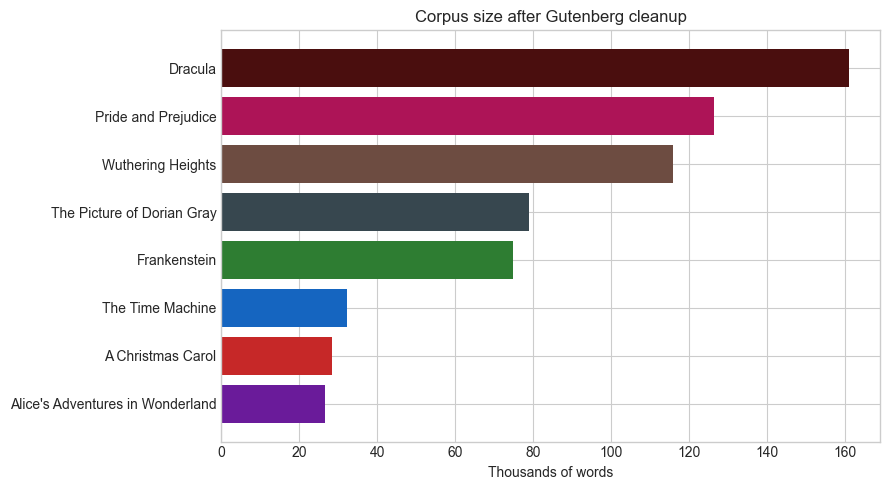

In [3]:
order = summary.sort_values('words')
colors = [BOOK_COLORS[b] for b in order['book_id']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order['title'], order['words'] / 1000, color=colors)
ax.set_xlabel('Thousands of words')
ax.set_title('Corpus size after Gutenberg cleanup')
plt.tight_layout()
fig_dir = PROJ_DIR / 'figures'
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / '01_corpus_lengths.png', dpi=120)
plt.show()


## A sample page

The first page of *Dracula* after boilerplate has been stripped:

In [4]:
sample = PAGES.loc[PAGES['book_id'] == 'dracula'].iloc[0]
print(f"Chapter: {sample['chapter_title']}")
print(f"Words: {sample['n_words']}")
print()
print(sample['text'][:900] + '…')


Chapter: CHAPTER XXVII. Mina Harker’s Journal
Words: 78

How these papers have been placed in sequence will be made manifest in the reading of them. All needless matters have been eliminated, so that a history almost at variance with the possibilities of later-day belief may stand forth as simple fact. There is throughout no statement of past things wherein memory may err, for all the records chosen are exactly contemporary, given from the standpoints and within the range of knowledge of those who made them. DRACULA…


## Page-window diagnostics

Most pages sit near the 250-word target. Short remainder pages are merged into the previous window so the series is not spiked by a 20-word tail.

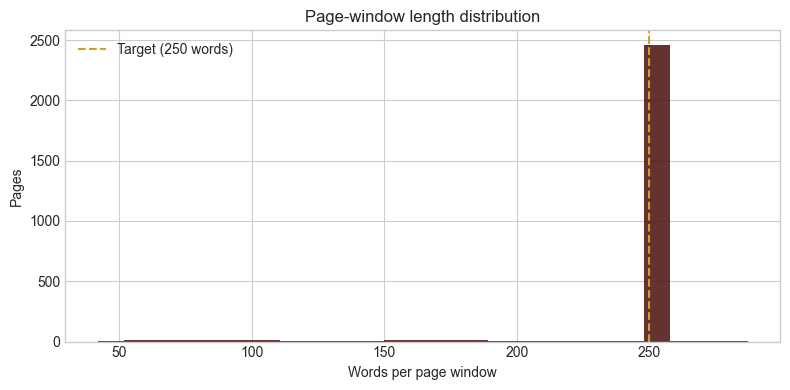

,words_per_page
count,2653.000000
mean,242.885036
std,31.284637
min,42.000000
25%,250.000000
50%,250.000000
75%,250.000000
max,287.000000


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(PAGES['n_words'], bins=25, color='#4a0e0e', alpha=0.85)
ax.axvline(250, color='#c9a227', linestyle='--', label='Target (250 words)')
ax.set_xlabel('Words per page window')
ax.set_ylabel('Pages')
ax.set_title('Page-window length distribution')
ax.legend()
plt.tight_layout()
plt.show()
PAGES['n_words'].describe().to_frame('words_per_page')


## Attribution

Plain-text ebooks from [Project Gutenberg](https://www.gutenberg.org/). See `data/README.md` for Gutenberg IDs and the rebuild command.

---

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Sentiment Trajectories →](02_sentiment.ipynb)
